In [1521]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import chi2, norm, chisquare, kstest, expon
from statsmodels.sandbox.stats.runs import runstest_1samp
import time
import pandas as pd
import heapq
import random
import math
from scipy import stats




# Stochastic Simulation

## Day 1 

### Exercise 1

#### (a)

In [1522]:
# Implementation of linear congruential generator
def LCG(x0, a, c, M, iter): 
    """
    Generate random numbers using a linear congrential generator
    Input: 
        x0: Initial value 
        a: Multiplier 
        c: Increment 
        M: Modulus 
        Iter: How many number iterations

    Output: A list of random number of length iter + 1.      
    """

    # Set initial value  
    x = x0 
    Numbers = [x/M]

    # Generate Random Numbers 
    for i in range(iter):
        x = (a*x + c) % M 
        U = x/M 
        Numbers.append(U)
    return Numbers

In [1523]:
# Test 1, values as of slides to check if function works correctly
x0 = 3 
M = 16 
a = 5 
c = 1
iter = 16
LCG(x0, a, c, M, iter)

[0.1875,
 0.0,
 0.0625,
 0.375,
 0.9375,
 0.75,
 0.8125,
 0.125,
 0.6875,
 0.5,
 0.5625,
 0.875,
 0.4375,
 0.25,
 0.3125,
 0.625,
 0.1875]

In [1524]:
# # Test 2, BAD random numbers 
x0 = 3 
M = 16 
a = 5 
c = 1
iter = 10000 
RN = LCG(x0, a, c, M, iter)
RN

[0.1875,
 0.0,
 0.0625,
 0.375,
 0.9375,
 0.75,
 0.8125,
 0.125,
 0.6875,
 0.5,
 0.5625,
 0.875,
 0.4375,
 0.25,
 0.3125,
 0.625,
 0.1875,
 0.0,
 0.0625,
 0.375,
 0.9375,
 0.75,
 0.8125,
 0.125,
 0.6875,
 0.5,
 0.5625,
 0.875,
 0.4375,
 0.25,
 0.3125,
 0.625,
 0.1875,
 0.0,
 0.0625,
 0.375,
 0.9375,
 0.75,
 0.8125,
 0.125,
 0.6875,
 0.5,
 0.5625,
 0.875,
 0.4375,
 0.25,
 0.3125,
 0.625,
 0.1875,
 0.0,
 0.0625,
 0.375,
 0.9375,
 0.75,
 0.8125,
 0.125,
 0.6875,
 0.5,
 0.5625,
 0.875,
 0.4375,
 0.25,
 0.3125,
 0.625,
 0.1875,
 0.0,
 0.0625,
 0.375,
 0.9375,
 0.75,
 0.8125,
 0.125,
 0.6875,
 0.5,
 0.5625,
 0.875,
 0.4375,
 0.25,
 0.3125,
 0.625,
 0.1875,
 0.0,
 0.0625,
 0.375,
 0.9375,
 0.75,
 0.8125,
 0.125,
 0.6875,
 0.5,
 0.5625,
 0.875,
 0.4375,
 0.25,
 0.3125,
 0.625,
 0.1875,
 0.0,
 0.0625,
 0.375,
 0.9375,
 0.75,
 0.8125,
 0.125,
 0.6875,
 0.5,
 0.5625,
 0.875,
 0.4375,
 0.25,
 0.3125,
 0.625,
 0.1875,
 0.0,
 0.0625,
 0.375,
 0.9375,
 0.75,
 0.8125,
 0.125,
 0.6875,
 0.5,
 0.5625,
 

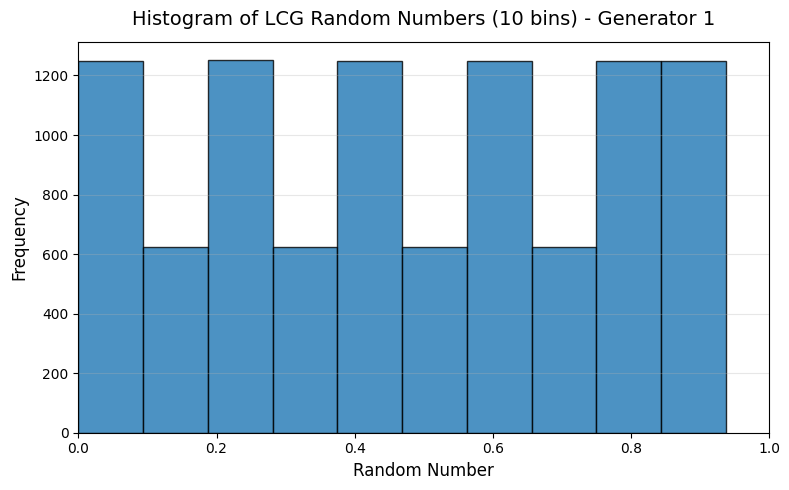

In [1525]:
bins = 10

plt.figure(figsize=(8, 5))

plt.hist(
    RN,
    bins=bins,
    edgecolor="black",
    linewidth=1,
    alpha=0.8
)

plt.title(
    f"Histogram of LCG Random Numbers ({bins} bins) - Generator 1",
    fontsize=14,
    pad=12
)
plt.xlabel("Random Number", fontsize=12)
plt.ylabel("Frequency", fontsize=12)

plt.xlim(0, 1)
plt.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

#### (b)

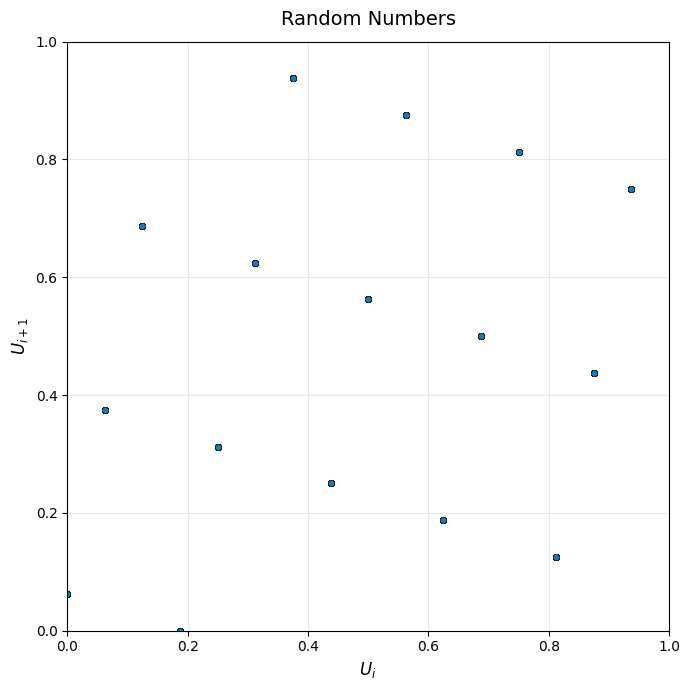

In [1526]:
# Scatterplot 

plt.figure(figsize=(7, 7))

plt.scatter(
    RN[:-1],
    RN[1:],
    s=20,          # marker size
    alpha=0.6,     # transparency
    edgecolors='black',
    linewidths=0.3
)

plt.title("Random Numbers", fontsize=14, pad=12)
plt.xlabel(r"$U_i$", fontsize=12)
plt.ylabel(r"$U_{i+1}$", fontsize=12)

plt.grid(alpha=0.3)
plt.xlim(0, 1)
plt.ylim(0, 1)

plt.tight_layout()
plt.show()

In [1527]:
# Define function to do a Chi-squared test 

def T_chi_square(n_observed, n_expected, m): 
    """
    Do a chi_square test
    Input: 
        n_observed: Array with the number of observed numbers at each bin 
        n_expected: The expected number of numbers at each bin given the expected distribution 
        m: The number of estimated parameters 
    
    Output: The p_value for hypothesis test 
    """
    
    n_observed = np.asarray(n_observed, dtype=float)
    n_expected = np.asarray(n_expected, dtype=float)
    n = len(n_observed)
    df = n-1-m
    T = np.sum(((n_observed-n_expected)**2)/n_expected)
    return chi2.sf(T,df)



In [1528]:
# Chi-squared test with 10 bins

bins = 10
observed, _ = np.histogram(RN, bins=bins)
expected = np.ones(bins) * (10000 / bins)


print(f"p-value of chi_square test {T_chi_square(observed,expected, 0)}") #Small p-value, very unlikely that derivation so large if the data followed a uniform distribution 

p-value of chi_square test 4.0029422697053997e-196


In [1529]:
def ecdf(x,obs): 
    """
    Compute the emperical cdf
    Input: 
        x: Float, value we want to evaluate the cdf. 
        obs: list of observations 
    Output: Emperical cdf evaluated at x
    """

    obs = np.array(obs)

    ecdf = np.sum(obs <= x)/len(obs)
    return ecdf

def uniform_cdf(x, a=0, b=1):
    """ 
    Compute theortical uniform cdf 

    Input: 
        x: Float, value we want to evaluate the cdf. 
    Output: Uniform cdf value evaluate at x. 
    """
    if x < a:
        return 0.0
    elif x > b:
        return 1.0
    else:
        return (x - a) / (b - a)

def Kolmogorov_Smirnov(obs): 
    """
    Compute D_n for the Kolmogorov Smirnov test 

    Input: 
        obs: list of observations 
    
        Output: D_n 
    """
    x = np.linspace(0,1,100)
    F_n = []
    F = []
    for val in x:
        F_n.append(ecdf(val, obs))
        F.append(uniform_cdf(val))
    D_n = np.max(abs(np.array(F_n)- np.array(F)))

    return D_n


In [1530]:
# Compute D_n
D_n = Kolmogorov_Smirnov(RN)

# Adjusted test statistic 
n = len(RN)

print(f"Adjusted D_n: {(np.sqrt(n) + 0.12 + 0.11/np.sqrt(n))*D_n}") # Not good result see slide 22

Adjusted D_n: 6.257255513199329


In [1531]:
# Wald-Wolfowitz run test

def Wald_Wolfowitz(obs):
    """
    Do a Wald Wolfowitz run test 
    Input: 
        obs: list of observations 
    
        Output: p-value of the Wald Wolfowitz run test 
    """

    # Compute median 
    median = np.median(obs)
    above_below = []

    # Check if values in observations is above or below the median 
    for x in obs:
        if x > median:
            above_below.append(1)
        if x <= median: 
            above_below.append(0)
    
    # Compute the number of observation above and below the median 
    n1 = np.sum(above_below)
    n2 = len(above_below) - n1 
    runs = 1 
    # Count the number of runs 
    for i in range(1,len(above_below)):
        if above_below[i] != above_below[i-1]:
            runs += 1
    
    T = runs 
 
    # Compute the test statistik z for the p-value 
    mean = 2*n1*n2/(n1 + n2) +1 
    var = 2*(n1*n2*(2*n1*n2 -n1 - n2)/( (n1+n2)**2*(n1 + n2 -1)))
    z = (T - mean)/np.sqrt(var)
    
    p_values = 2*norm.sf(abs(z))
    return p_values
    


In [1532]:
# Run test 1 (Above/below)
print(f"Above below run test p-value {Wald_Wolfowitz(RN)}")

Above below run test p-value 4.759054458520932e-138


In [1533]:
def knuth(obs):
    """
    Do Knuth's run-length test 
    Input: 
        obs: list of observations 
    
        Output: p-value of the Knuth's run-length test 
    """
    obs = np.array(obs)
    n = len(obs)

    # Compute increasing runs
    lengths = []
    current_len = 1

    for i in range(1, n):
        if obs[i] > obs[i - 1]:
            current_len += 1
        else:
            lengths.append(current_len)
            current_len = 1

    
    # Find the R vector 
    R = np.zeros(6)
    for r in lengths:
        if r <= 5: 
            R[r-1] += 1 
        else: 
            R[5] += 1 
    
    # Define A and B
    A = np.array([
    [4529.4,  9044.9, 13568, 18091, 22615, 27892],
    [9044.9, 18097, 27139, 36187, 45234, 55789],
    [13568, 27139, 40721, 54281, 67852, 83685],
    [18091, 36187, 54281, 72414, 90470, 111580],
    [22615, 45234, 67852, 90470, 113262, 139476],
    [27892, 55789, 83685, 111580, 139476, 172860]
    ])

    B = np.array([
    [1/6],
    [5/24],
    [11/120],
    [19/720],
    [29/5040],
    [1/840]
    ])

    
    d = R - n*B.flatten()
    Z = (d.T @ A @ d) / (n - 6)
    


    
    df = 6
    p_value = chi2.sf(Z,df)
  
    return p_value
            
    

In [1534]:
# Knuth run test (up/down)
print(f"Up/down run test p-value: {knuth(RN)}")

Up/down run test p-value: 1.4733787998841428e-238


In [1535]:
def correlation_test(obs,h):
    """ 
    Do a correlation test 
    Input: 
        obs: list of observations 
        h: lag 
    
    Output: p-value for the correlation test 
    """
    obs = np.array(RN)
    n= len(obs)
    c = np.sum(obs[:-h] * obs[h:]) / (n - h)

    mean = 0.25
    var = 7/(144*n)
    z = (c - mean)/np.sqrt(var)
    
    p_values = 2*norm.sf(abs(z))
    return p_values

In [1536]:
h = [1,3,5,6]
for element in h: 
    print(f"p-value correlation test: {correlation_test(RN,element)}, h = {element}")


p-value correlation test: 0.00039471242218985114, h = 1
p-value correlation test: 1.1720063046768725e-135, h = 3
p-value correlation test: 2.3477047724179072e-26, h = 5
p-value correlation test: 3.3930716474674713e-51, h = 6


#### (c)

In [1537]:

# GOOD example 
x0 = 2 
M = 2**32 
a = 1203515245
c = 12345
iter = 10000 
RN = LCG(x0, a, c, M, iter)


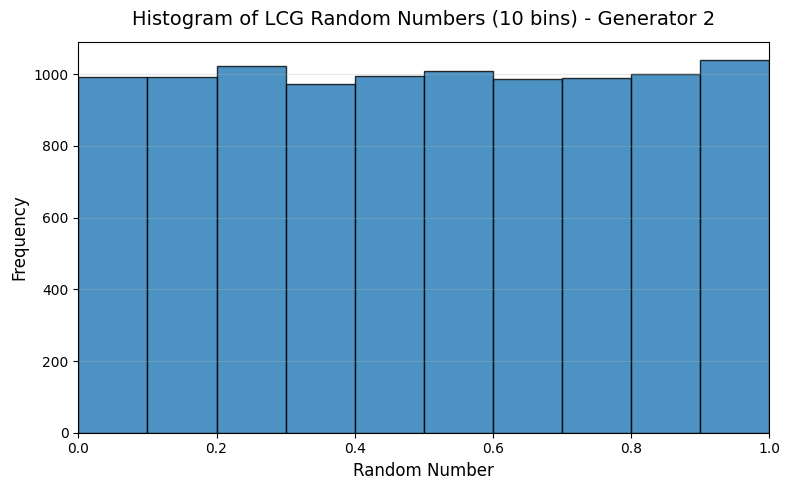

In [1538]:
# Histogram 
bins = 10

plt.figure(figsize=(8, 5))

plt.hist(
    RN,
    bins=bins,
    edgecolor="black",
    linewidth=1,
    alpha=0.8
)

plt.title(
    f"Histogram of LCG Random Numbers ({bins} bins) - Generator 2",
    fontsize=14,
    pad=12
)
plt.xlabel("Random Number", fontsize=12)
plt.ylabel("Frequency", fontsize=12)

plt.xlim(0, 1)
plt.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

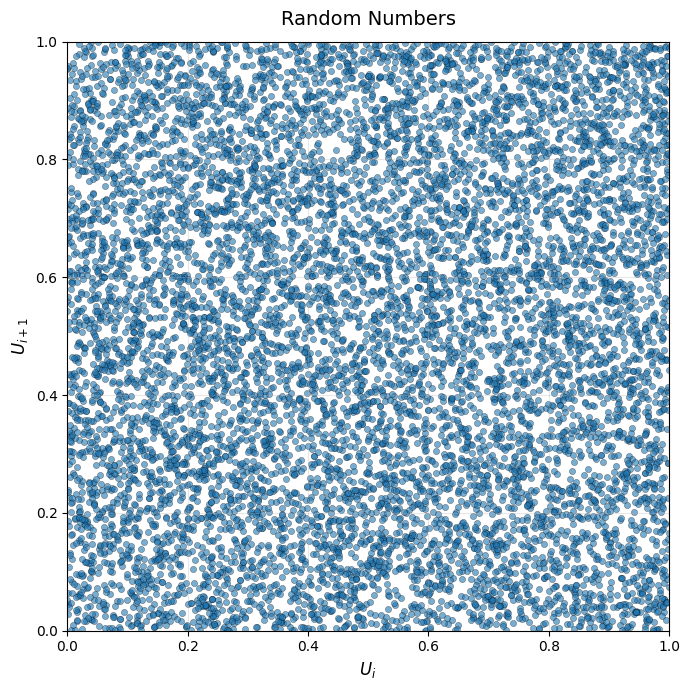

In [1539]:
# Scatterplot 

plt.figure(figsize=(7, 7))

plt.scatter(
    RN[:-1],
    RN[1:],
    s=20,          # marker size
    alpha=0.6,     # transparency
    edgecolors='black',
    linewidths=0.3
)

plt.title("Random Numbers", fontsize=14, pad=12)
plt.xlabel(r"$U_i$", fontsize=12)
plt.ylabel(r"$U_{i+1}$", fontsize=12)

plt.grid(alpha=0.3)
plt.xlim(0, 1)
plt.ylim(0, 1)

plt.tight_layout()
plt.show()

In [1540]:
# Chi-squared test with 10 bins

bins = 10
observed, _ = np.histogram(RN, bins=bins)
expected = np.ones(bins) * (10000 / bins)


print(f"p-value of chi_square test {T_chi_square(observed,expected, 0)}") 


p-value of chi_square test 0.9493265886655313


In [1541]:
# Compute D_n
D_n = Kolmogorov_Smirnov(RN)

# Adjusted test statistic 
print(f"Adjusted D_n: {(np.sqrt(n) + 0.12 + 0.11/np.sqrt(n))*D_n}") 

Adjusted D_n: 0.5197946398035579


In [1542]:
# Run test 1 (Above/below)
print(f"Above below run test p-value {Wald_Wolfowitz(RN)}")

Above below run test p-value 0.02852430695565274


In [1543]:
# Knuth run test (up/down)
print(f"Up/down run test p-value: {knuth(RN)}")

Up/down run test p-value: 0.16447844145177415


In [1544]:
h = [1,3,5,6]
for element in h: 
    print(f"p-value correlation test: {correlation_test(RN,element)},h = {element}")

p-value correlation test: 0.15144114303806372,h = 1
p-value correlation test: 0.7155167285473527,h = 3
p-value correlation test: 0.3632782844797088,h = 5
p-value correlation test: 0.40690599290045637,h = 6


### Exercise 2 

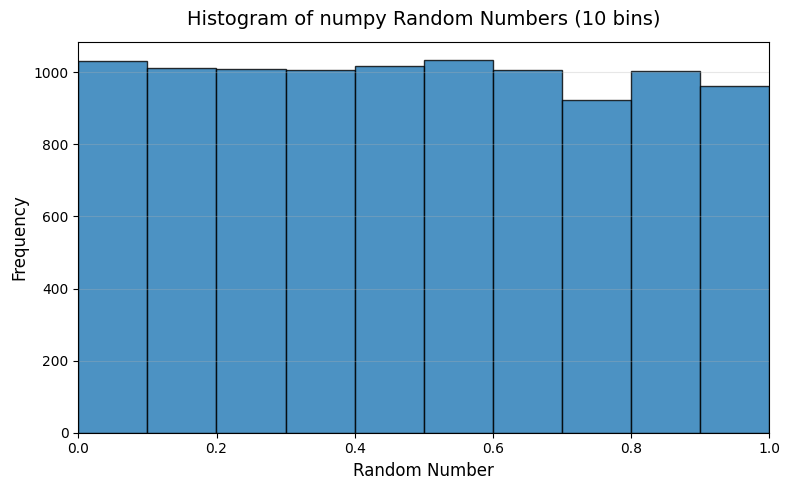

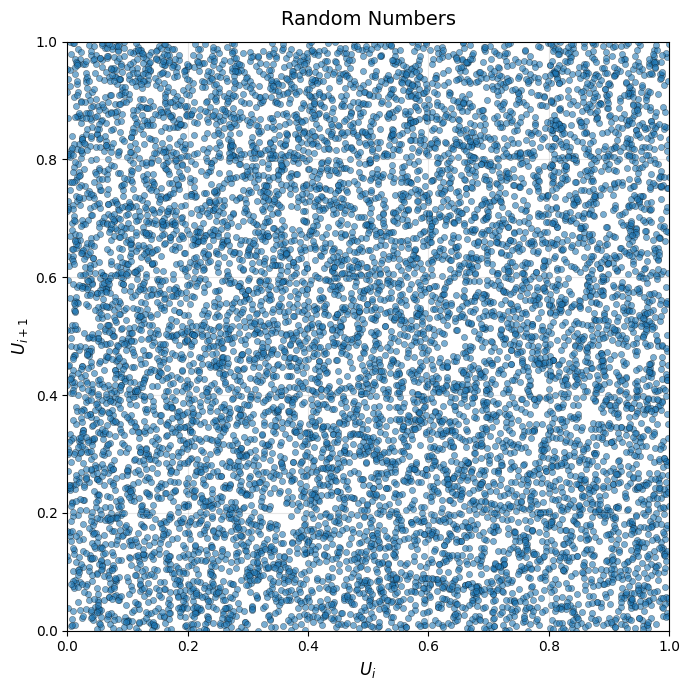

p-value of chi_square test 0.34245050415591705
Adjusted D_n: 1.1945347120950862
Above below run test p-value: 0.21495245879429403
Up/down run test p-value: 0.9728879316473026
p-value correlation test: 0.15144114303806372, h = 1
p-value correlation test: 0.7155167285473527, h = 3
p-value correlation test: 0.3632782844797088, h = 5
p-value correlation test: 0.40690599290045637, h = 6


In [1545]:
np.random.seed(42)
RN_sys = np.random.rand(10000)

# Histogram 
bins = 10

plt.figure(figsize=(8, 5))

plt.hist(
    RN_sys,
    bins=bins,
    edgecolor="black",
    linewidth=1,
    alpha=0.8
)

plt.title(
    f"Histogram of numpy Random Numbers ({bins} bins)",
    fontsize=14,
    pad=12
)
plt.xlabel("Random Number", fontsize=12)
plt.ylabel("Frequency", fontsize=12)

plt.xlim(0, 1)
plt.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

# Scatterplot 

plt.figure(figsize=(7, 7))

plt.scatter(
    RN_sys[:-1],
    RN_sys[1:],
    s=20,          # marker size
    alpha=0.6,     # transparency
    edgecolors='black',
    linewidths=0.3
)

plt.title("Random Numbers", fontsize=14, pad=12)
plt.xlabel(r"$U_i$", fontsize=12)
plt.ylabel(r"$U_{i+1}$", fontsize=12)

plt.grid(alpha=0.3)
plt.xlim(0, 1)
plt.ylim(0, 1)

plt.tight_layout()
plt.show()

# Chi-squared test with 10 bins

bins = 10
bins = 10
observed, _ = np.histogram(RN_sys, bins=bins)
expected = np.ones(bins) * (10000 / bins)


print(f"p-value of chi_square test {T_chi_square(observed,expected, 0)}") 

# Compute D_n
D_n = Kolmogorov_Smirnov(RN_sys)

# Adjusted test statistic 
print(f"Adjusted D_n: {(np.sqrt(n) + 0.12 + 0.11/np.sqrt(n))*D_n}") 

# Run test 1 (Above/below)
print(f"Above below run test p-value: {Wald_Wolfowitz(RN_sys)}")

# Knuth run test (up/down)
print(f"Up/down run test p-value: {knuth(RN_sys)}")

h = [1,3,5,6]
for element in h: 
    print(f"p-value correlation test: {correlation_test(RN_sys,element)}, h = {element}")


### Exercise 3

The problem with this approach is that it is deterministic. Given the inital values we will obtain one sequence of numbers, that we can evalute the distribution on. Ideally we should use the LCG model to generate more sequences of number, so that we can check how good the method is. One could get "lucky" and have a good inital number, when in reality the generator could perform badly in most cases. Next step would be to generate many sequences and compare. In the following we only check if the sequence pass the chi_square test. We only change the starting point

In [1546]:
seeds = np.arange(1, 501) 
M = 2**32 
a = 1203515245
c = 12345
iter = 10000 

Number_of_passed = 0 
p_values = []
for element in seeds: 
    RN = LCG(element, a, c, M, iter)
    bins = 10
    bins = 10
    observed, _ = np.histogram(RN, bins=bins)
    expected = np.ones(bins) * (iter / bins)
    p = T_chi_square(observed,expected, 0)
    
    if p >= 0.005: 
        p_values.append(p)
        Number_of_passed += 1


print(f"Number of passed sequences: {Number_of_passed} for a = {a}, M = {M}, c = {c}.")

Number of passed sequences: 498 for a = 1203515245, M = 4294967296, c = 12345.


In [1547]:
seeds = np.arange(1, 501) 
M = 16 
a = 5 
c = 1
iter = 10000 

Number_of_passed = 0 
p_values = []
for element in seeds: 
    RN = LCG(element, a, c, M, iter)
    bins = 10
    bins = 10
    observed, _ = np.histogram(RN, bins=bins)
    expected = np.ones(bins) * (iter / bins)
    p = T_chi_square(observed,expected, 0)
    
    if p >= 0.005: 
        p_values.append(p)
        Number_of_passed += 1

print(f"Number of passed sequences: {Number_of_passed} for a = {a}, M = {M}, c = {c}.")

Number of passed sequences: 0 for a = 5, M = 16, c = 1.


## Day 2 

### Exercise 2

#### Part 1

In [1548]:
# Test example to make geometric sample 
p = 0.3 
n = 10000

np.random.seed(42)
U = np.random.rand(n)

geometric_sample = np.floor(np.log(U)/np.log(1-p)) + 1
geometric_sample


array([3., 1., 1., ..., 1., 3., 5.], shape=(10000,))

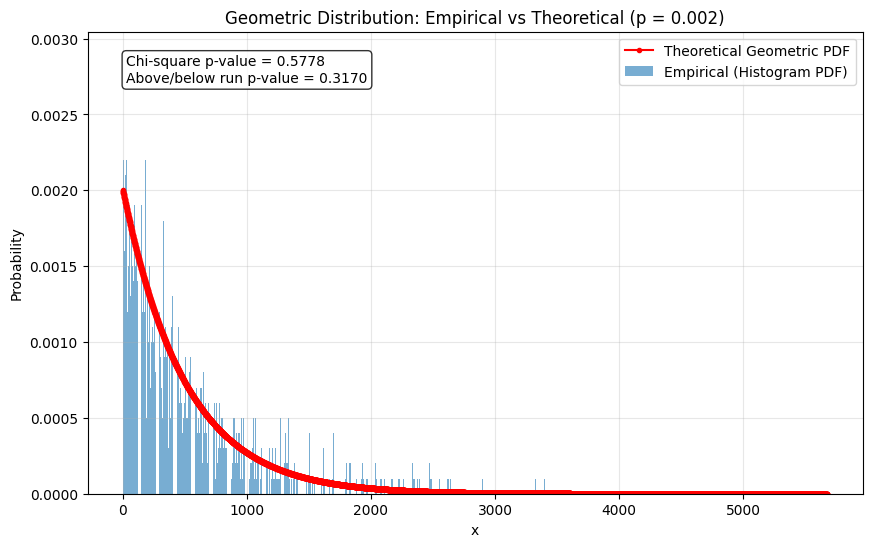

Chi-square p-value: 0.5777722599192963
Above/below run p-value: 0.3170497936724864


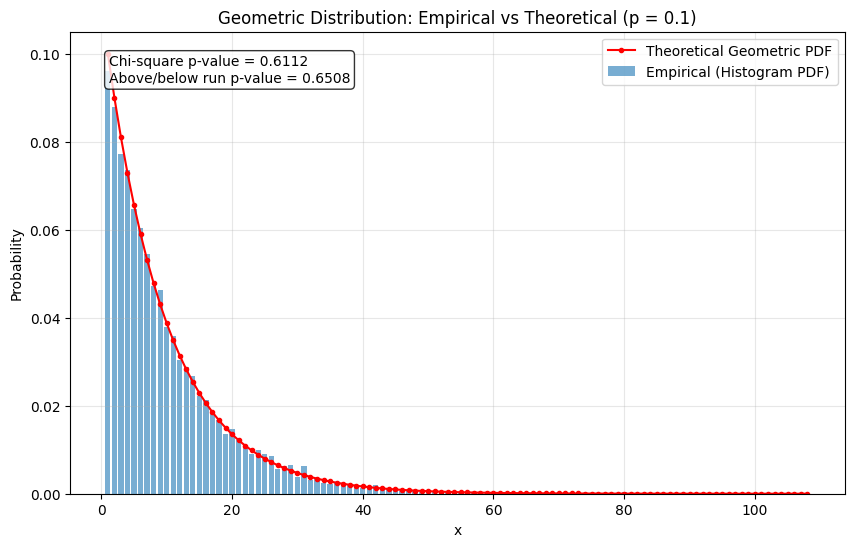

Chi-square p-value: 0.6111663260385857
Above/below run p-value: 0.6508375002402667


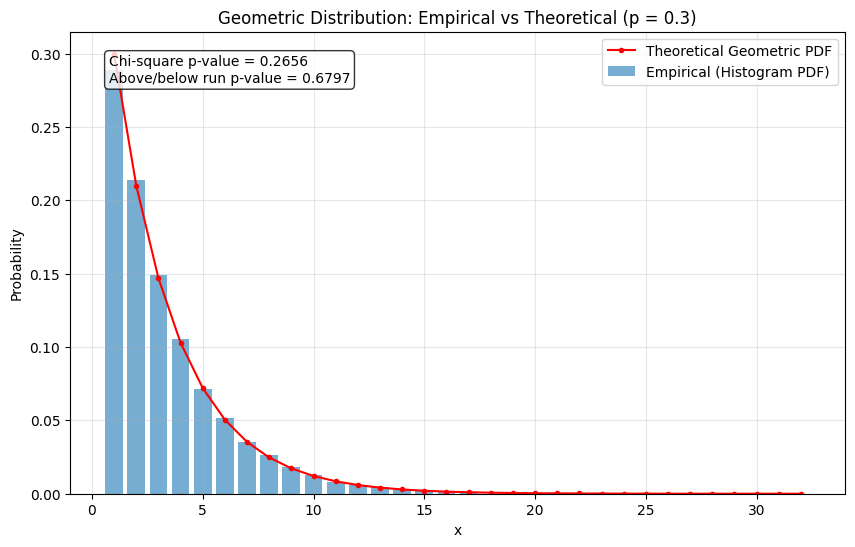

Chi-square p-value: 0.2655817547572496
Above/below run p-value: 0.679732994646891


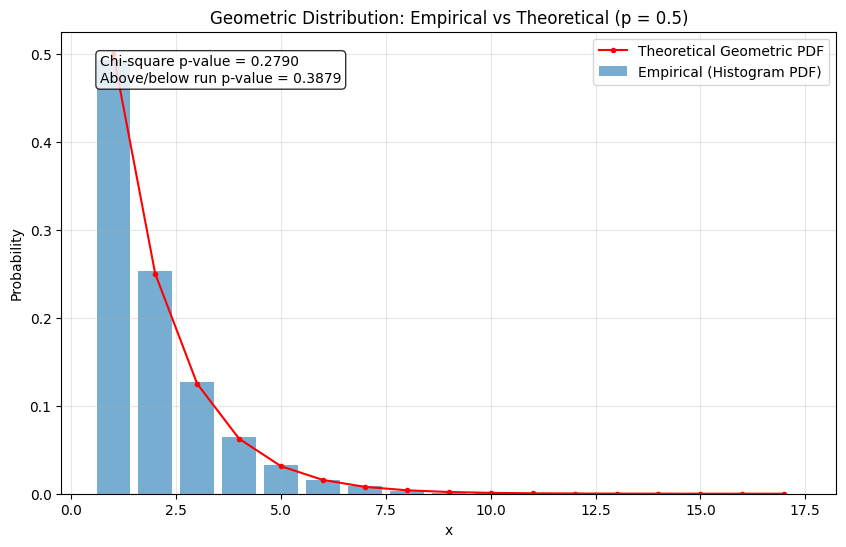

Chi-square p-value: 0.2790052223365163
Above/below run p-value: 0.38794690237893914


/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/statsmodels/sandbox/stats/runs.py:102: RuntimeWarning: invalid value encountered in scalar divide
  z /= rstd


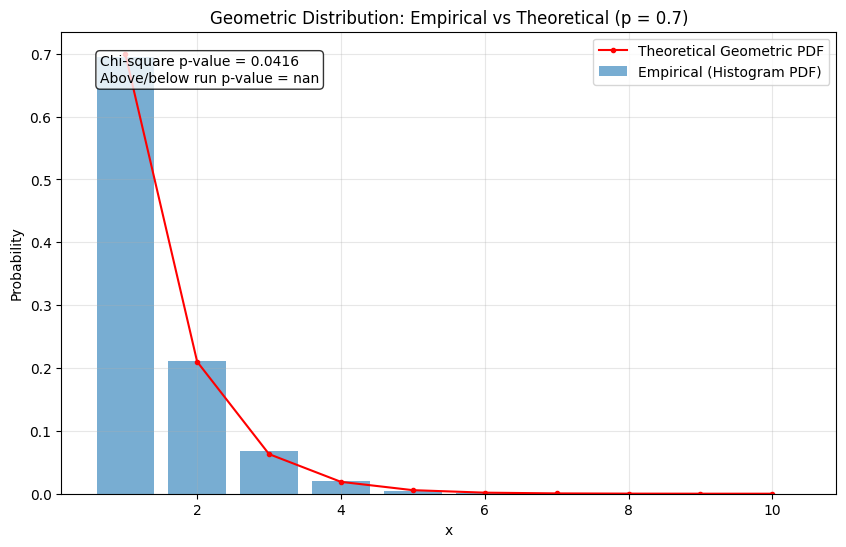

Chi-square p-value: 0.041554385418533846
Above/below run p-value: nan


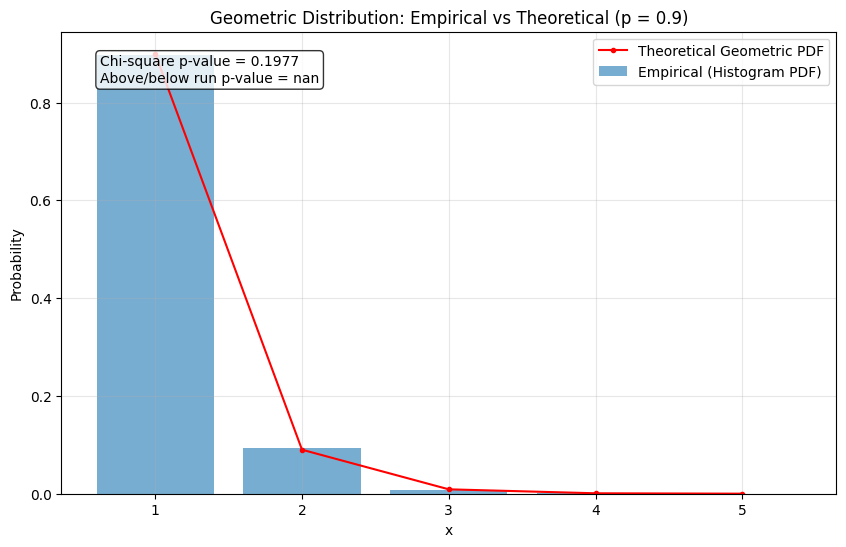

Chi-square p-value: 0.19765763629787836
Above/below run p-value: nan


In [1549]:
# Simulated geometric distributions for different values of p
p = [0.002,0.1,0.3,0.5,0.7,0.9]

for element in p: 
    # Simulate geometric sample 
    np.random.seed(42)
    n = 10000
    U = np.random.rand(n)
    geometric_sample = (np.floor(np.log(U)/np.log(1-element))).astype(int) + 1

    max_x = geometric_sample.max()
    x_vals = np.arange(1, max_x + 1)   

    obs_counts = np.bincount(geometric_sample, minlength=max_x+1)[1:]
    hist_pdf = obs_counts / n

    # Theorical pdf

    theoretical_pdf = element * (1 - element) ** (x_vals - 1)
    exp_counts = theoretical_pdf * n
  
    mask = exp_counts >= 5
    obs = obs_counts[mask]
    exp = exp_counts[mask]

    # Do chi-square test 
    exp = exp * (obs.sum() / exp.sum())
    chi_stat, p_value_chi = chisquare(f_obs=obs, f_exp=exp)
    
    # Do above/below run test 
    z_stat, p_value_run = runstest_1samp(geometric_sample, cutoff="median")

    # Plot theorical distribution vs. simulated distribution 
    plt.figure(figsize=(10, 6))
    plt.bar(x_vals, hist_pdf, alpha=0.6, label="Empirical (Histogram PDF)")
    plt.plot(x_vals, theoretical_pdf, 'r-', marker='o', markersize=3,
         label="Theoretical Geometric PDF")

    plt.title(f"Geometric Distribution: Empirical vs Theoretical (p = {element})")
    plt.xlabel("x")
    plt.ylabel("Probability")

    text = (
    f"Chi-square p-value = {p_value_chi:.4f}\n"
    f"Above/below run p-value = {p_value_run:.4f}"
     )
    plt.text(
    0.05, 0.95,
    text,
    transform=plt.gca().transAxes,
    va='top',
    bbox=dict(boxstyle='round', facecolor='white', alpha=0.8)
     )

    plt.legend()
    plt.grid(alpha=0.3)

    plt.show()
    print("Chi-square p-value:", p_value_chi)
    print("Above/below run p-value:", p_value_run)
    
    

#### Part 2

##### (1)

In [1550]:
np.random.seed(42)

def crude(x, p, n):
    """
    Generate oberservations from discrete distribution using the crude method 

    Input: 
        x: np.array of possible outcomes 
        p: np.array of probability of each outcome 
        n: number of observations 
    
    Output: Simulated samples using the crude method
    """
    # Generete samples using crude method
    U = np.random.rand(n)
    intervals = np.cumsum(p)
    index = np.searchsorted(intervals, U, side='left')
    X = x[index]



    return X


In [1551]:
def plot_theoritical_emperical_dis(samples, x, p, method):
    # Observed relative frequencies
        observed = np.bincount(samples)[1:] / n

        plt.figure(figsize=(8, 5))

        # Observed
        plt.bar(
            x,
            observed,
            width=0.7,
            alpha=0.7,
            edgecolor="black",
            label="Observed"
        )

        # Theoretical
        plt.plot(
            x,
            p,
            marker="o",
            linewidth=2,
            label="Theoretical",
            color = "red"
        )

        # Plot distribution
        plt.title(f"{method} Method: Observed vs Theoretical Distribution",
                fontsize=14, pad=12)
        plt.xlabel("Outcome", fontsize=12)
        plt.ylabel("Probability", fontsize=12)

        plt.xticks(x)
        plt.grid(axis="y", alpha=0.3)
        plt.legend()

        plt.tight_layout()
        return plt.show()

In [1552]:
x = np.array([1,2,3,4,5,6])
p = np.array([7/48, 5/48, 1/8, 1/16, 1/4, 5/16])

n = 10000
samples_crude = crude(x, p, n)
samples_crude

array([3, 6, 6, ..., 6, 4, 2], shape=(10000,))

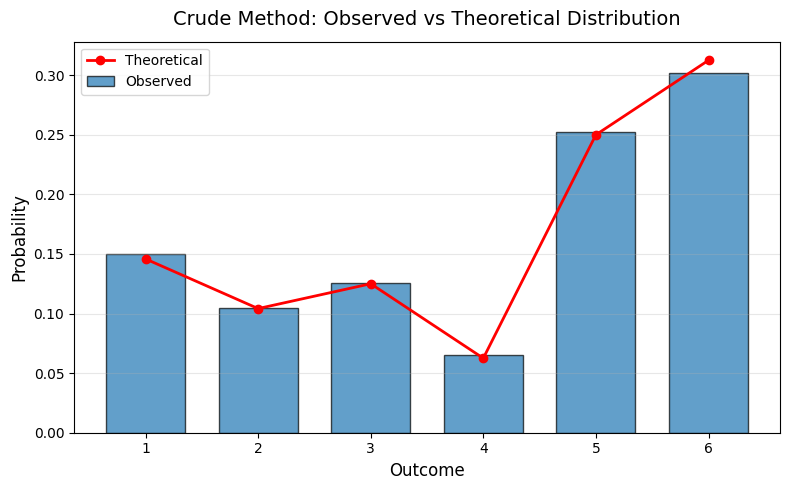

In [1553]:
plot_theoritical_emperical_dis(samples_crude, x, p, "Crude")

##### (2)

In [1554]:
# Rejection method 

def simple_rejection_method(x,p,n,c): 
    """
    Generate oberservations from discrete distribution using the crude method 

    Input: 
        x: np.array of possible outcomes 
        p: np.array of probability of each outcome 
        n: number of observations 
        c: constant bigger that max(p)
    
    Output: Simulated samples using the rejection method
    """
    
    # Generete samples using the rejection method
    k = np.max(x)
    X = []
    while len(X) < n:
        U1 = np.random.rand()

        I = (np.floor(k*U1) + 1).astype(int)
        pI = p[I-1] 
        if np.random.rand() <= pI/c: 
            X.append(I)


    return np.array(X)

x = np.array([1,2,3,4,5,6])
p = [7/48,5/48, 1/8, 1/16,1/4,5/16]
#print(np.max(p))
c = 0.32
n = 10000
k = np.max(x)

samples_rejection = simple_rejection_method(x,p,n,c)

samples_rejection


array([3, 5, 6, ..., 1, 6, 1], shape=(10000,))

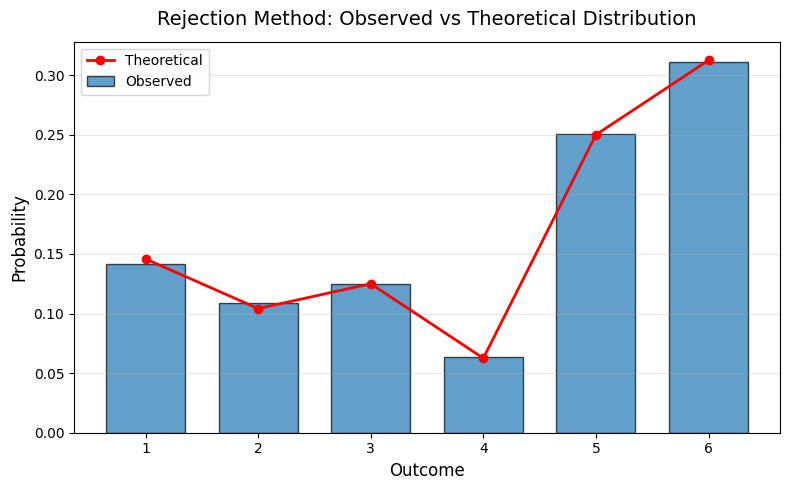

In [1555]:
plot_theoritical_emperical_dis(samples_rejection, x, p, "Rejection")

##### (3)

In [1556]:
def alias_setup(p, eps=1e-12):
    """ 
    Compute F and L for the alias method

    Input: 
        p: np.array of probability of each outcome 
    
    Output: 
        F: np.array with the F vector 
        L: np.array with the L vector
    """
    p = np.asarray(p, dtype=float)
    k = len(p)


    #  Initialize L Using 0-based 
    L = np.arange(k)

    # Initialize F 
    F = k * p.copy()

    # Find G and S 
    G = list(np.where(F >= 1)[0])
    S = list(np.where(F <= 1)[0])

    
    while S:
        
        i = G[0]
        j = S[0]

        
        L[j] = i
        F[i] = F[i] - (1.0 - F[j])

        
        if F[i] < 1.0 - eps:
            G.pop(0)     
            S.append(i)   

        S.pop(0)

    return F, L 

# Check function 

p = [7/48,5/48, 1/8, 1/16,1/4,5/16]
F, L = alias_setup(p,eps=1e-12)
F,L



(array([0.875, 0.625, 0.75 , 0.375, 0.75 , 1.   ]), array([4, 4, 4, 5, 5, 5]))

In [1557]:
def alias_method(x, p, F, L, n):
    """
    Generate oberservations from discrete distribution using the alias method 

    Input: 
        x: np.array of possible outcomes 
        p: np.array of probability of each outcome 
        F: np.array with F vector computed by function alias_setup
        L: np.array with L vector computed by function alias_setup
        n: number of observations 
    
    Output: Simulated samples using the alias method
    """
    
    k = len(p)
    X = []

    # Generate samples using the alias method 

    while len(X) < n:
        I = np.random.randint(0, k)

        if np.random.rand() <= F[I]:
            X.append(I)
        else:
            X.append(L[I])

    X = np.array(X) + 1 # Want in 1-index
    

    return X 

In [1558]:

x = np.array([1,2,3,4,5,6])
p = [7/48,5/48, 1/8, 1/16,1/4,5/16]
n = 10000

# Compute F and L 
F, L = alias_setup(p,eps=1e-12)


samples_alias = alias_method(x,p,F,L,n)
samples_alias

array([2, 6, 2, ..., 5, 1, 4], shape=(10000,))

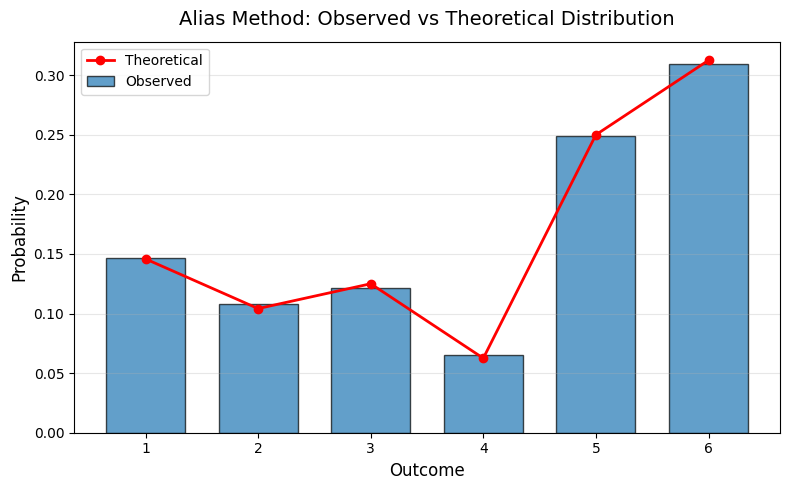

In [1559]:
plot_theoritical_emperical_dis(samples_alias, x, p, "Alias")

#### Part 3

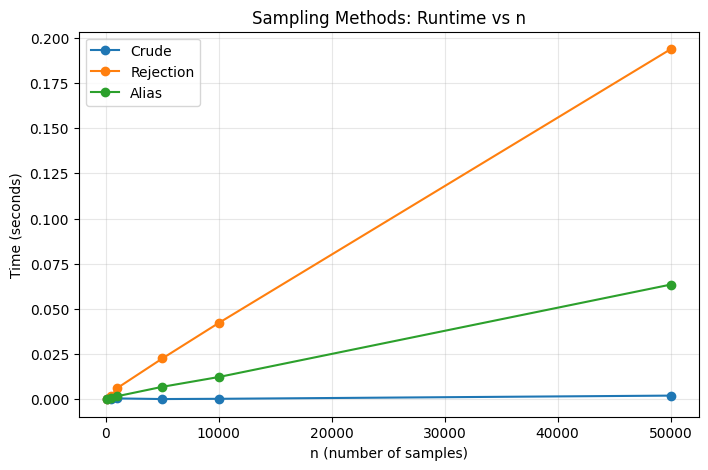

In [1560]:
# Computational efficiency (time)

# Problem setup

x = np.array([1,2,3,4,5,6])
p = np.array([7/48, 5/48, 1/8, 1/16, 1/4, 5/16])

k = len(x)
c = 0.32

# alias setup 
F, L = alias_setup(p, eps=1e-12)

# different sample sizes
ns = [100, 500, 1000, 5000, 10000, 50000]

# store results
t_crude_list = []
t_rej_list = []
t_alias_list = []

def time_func(func, *args):
    start = time.perf_counter()
    out = func(*args)
    end = time.perf_counter()
    return end - start

for n in ns:
    
    t1 = time_func(crude, x, p, n)
    t2 = time_func(simple_rejection_method, x, p, n, c)
    t3 = time_func(alias_method, x, p, F, L, n)

    t_crude_list.append(t1)
    t_rej_list.append(t2)
    t_alias_list.append(t3)


# Plot results

plt.figure(figsize=(8,5))

plt.plot(ns, t_crude_list, marker='o', label='Crude')
plt.plot(ns, t_rej_list, marker='o', label='Rejection')
plt.plot(ns, t_alias_list, marker='o', label='Alias')

plt.xlabel("n (number of samples)")
plt.ylabel("Time (seconds)")
plt.title("Sampling Methods: Runtime vs n")
plt.legend()
plt.grid(alpha=0.3)

plt.show()

Maybe crude is good is we have a efficent search algorithm? 

In [1561]:
# Accuracy of the generated distribution

x = np.array([1,2,3,4,5,6])
p = np.array([7/48, 5/48, 1/8, 1/16, 1/4, 5/16])

n = 10000
F, L = alias_setup(p, eps=1e-12)


# Generate samples

crude_samples = crude(x, p, n)
rej_samples = simple_rejection_method(x, p, n, 0.32)
alias_samples = alias_method(x, p, F, L, n)


# Empirical distributions

def empirical_dist(samples, x):
    counts = np.array([(samples == xi).sum() for xi in x])
    return counts / len(samples)

p_crude = empirical_dist(crude_samples, x)
p_rej = empirical_dist(rej_samples, x)
p_alias = empirical_dist(alias_samples, x)


# Error metrics

def l1_error(p_hat, p):
    return np.sum(np.abs(p_hat - p))

def l2_error(p_hat, p):
    return np.sqrt(np.sum((p_hat - p)**2))

print("L1 errors:")
print("Crude:", l1_error(p_crude, p))
print("Rejection:", l1_error(p_rej, p))
print("Alias:", l1_error(p_alias, p))

print("\nL2 errors:")
print("Crude:", l2_error(p_crude, p))
print("Rejection:", l2_error(p_rej, p))
print("Alias:", l2_error(p_alias, p))

# Chi-square test 
exp = n * p
obs_crude = np.array([
    np.sum(crude_samples == xi) for xi in x
])

obs_rej = np.array([
    np.sum(rej_samples == xi) for xi in x
])

obs_alias = np.array([
    np.sum(alias_samples == xi) for xi in x
])

# OBS p-value does not measure closeness only if we can reject the null-hypothesis 

_, p_value_crude = chisquare(f_obs=obs_crude, f_exp=exp)
_, p_value_rej = chisquare(f_obs=obs_rej, f_exp=exp)
_, p_value_alias = chisquare(f_obs=obs_alias, f_exp=exp)




print("\np-values Chi-square test:")
print("Crude:", p_value_crude)
print("Rejection:", p_value_rej)
print("Alias:", p_value_alias)




L1 errors:
Crude: 0.015199999999999922
Rejection: 0.021800000000000007
Alias: 0.01580000000000003

L2 errors:
Crude: 0.008096638534327379
Rejection: 0.010407796223131111
Alias: 0.0072610069702640015

p-values Chi-square test:
Crude: 0.6064404551519815
Rejection: 0.14691460582802943
Alias: 0.5772946770515829


In [1562]:
x = np.array([1,2,3,4,5,6])
p = np.array([7/48, 5/48, 1/8, 1/16, 1/4, 5/16])

F, L = alias_setup(p, eps=1e-12)


def run_experiment(n):
    crude_samples = crude(x, p, n)
    rej_samples = simple_rejection_method(x, p, n, 0.32)
    alias_samples = alias_method(x, p, F, L, n)

    p_crude = empirical_dist(crude_samples, x)
    p_rej = empirical_dist(rej_samples, x)
    p_alias = empirical_dist(alias_samples, x)

    return {
        "n": n,
        "crude_l1": l1_error(p_crude, p),
        "crude_l2": l2_error(p_crude, p),
        "rej_l1": l1_error(p_rej, p),
        "rej_l2": l2_error(p_rej, p),
        "alias_l1": l1_error(p_alias, p),
        "alias_l2": l2_error(p_alias, p),
    }


ns = [100, 500, 1000, 5000, 10000, 50000]

results = [run_experiment(n) for n in ns]
df = pd.DataFrame(results)

print(df)

       n  crude_l1  crude_l2    rej_l1    rej_l2  alias_l1  alias_l2
0    100  0.116667  0.058926  0.113333  0.056618  0.145000  0.075203
1    500  0.149667  0.063772  0.102333  0.050678  0.042000  0.020385
2   1000  0.048333  0.023070  0.024000  0.011190  0.052667  0.023485
3   5000  0.018533  0.008038  0.022800  0.011215  0.027200  0.011876
4  10000  0.015733  0.007135  0.010800  0.005628  0.012667  0.005921
5  50000  0.010640  0.004992  0.008320  0.004061  0.005920  0.003178


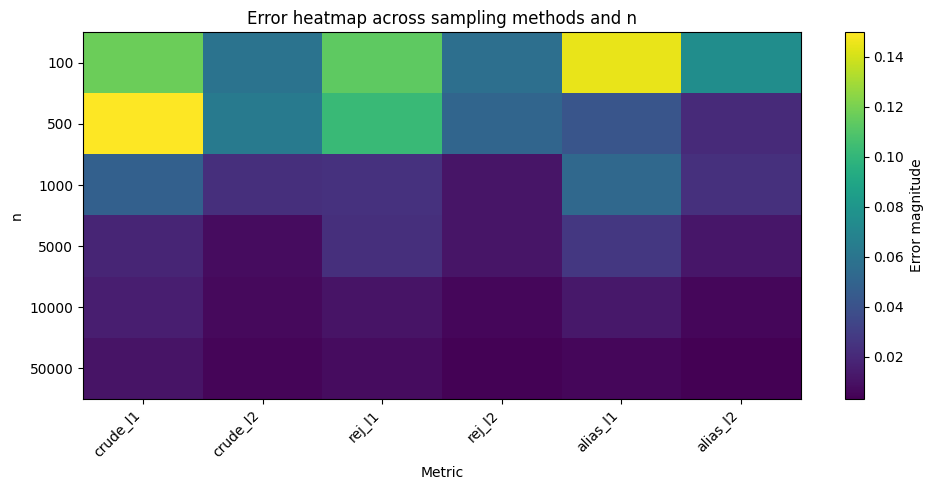

In [1563]:
df_heat = df.set_index("n")

plt.figure(figsize=(10, 5))

plt.imshow(df_heat.values, aspect='auto')

plt.xticks(
    ticks=np.arange(len(df_heat.columns)),
    labels=df_heat.columns,
    rotation=45,
    ha='right'
)

plt.yticks(
    ticks=np.arange(len(df_heat.index)),
    labels=df_heat.index
)

plt.colorbar(label="Error magnitude")

plt.title("Error heatmap across sampling methods and n")
plt.xlabel("Metric")
plt.ylabel("n")

plt.tight_layout()
plt.show()

#### Part 4

### Exercise 3

#### Part 1 

##### (1) Exponential Distribution

In [1564]:
# Exponential distribution
np.random.seed(42)

def exp_disp_gen(U, rate):
    return -np.log(U)/rate

pvalue: 0.295960147968341


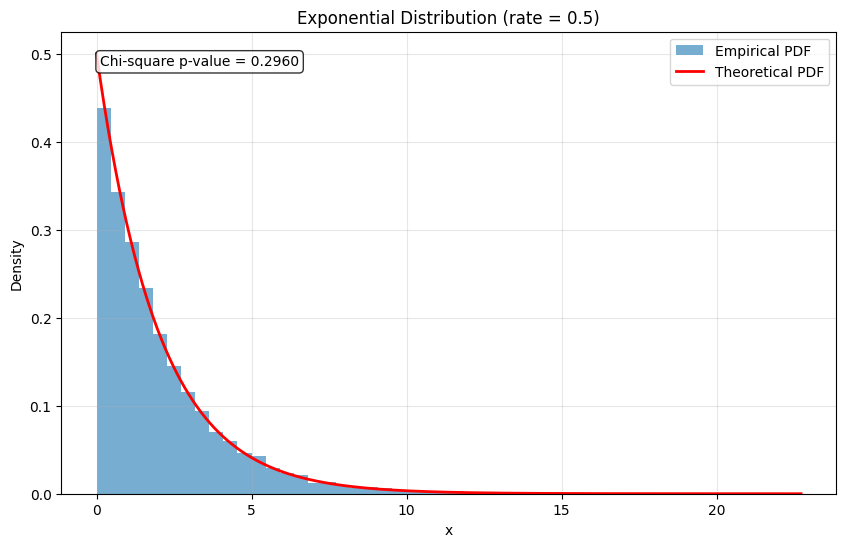

pvalue: 0.41252245692348505


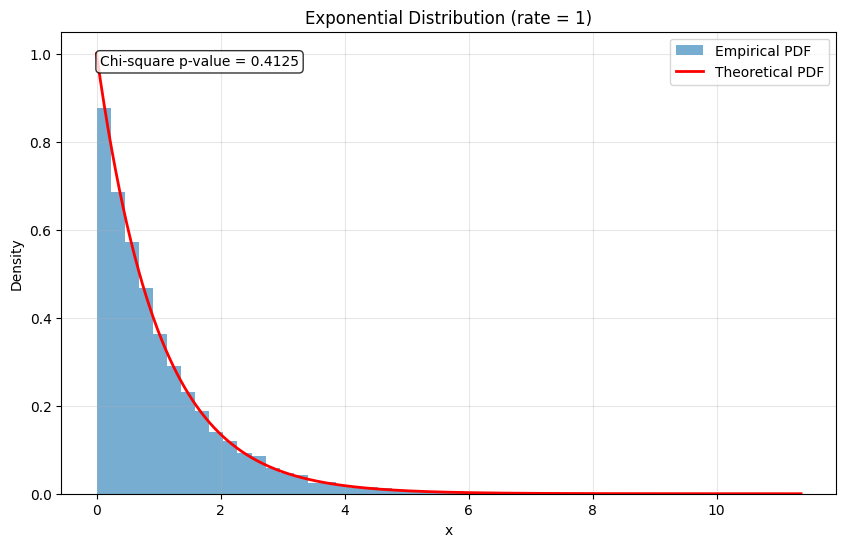

pvalue: 0.2496951749558816


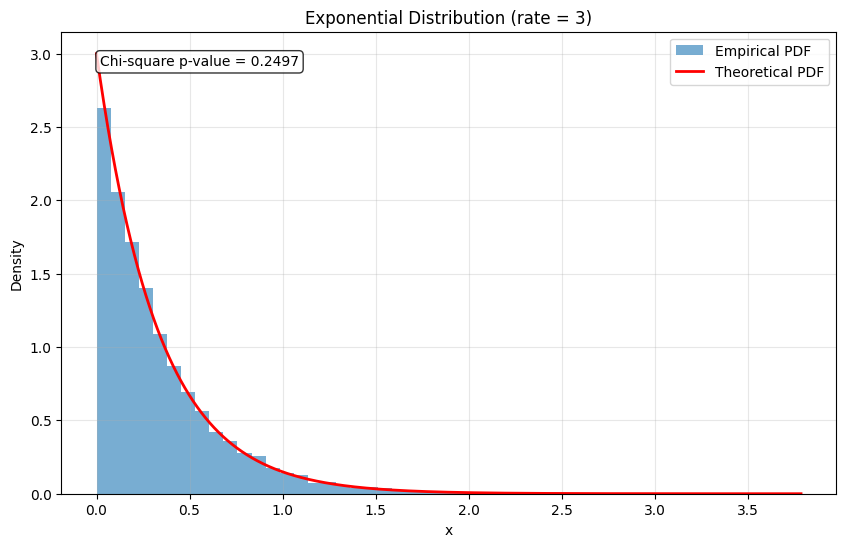

pvalue: 0.32407411813625087


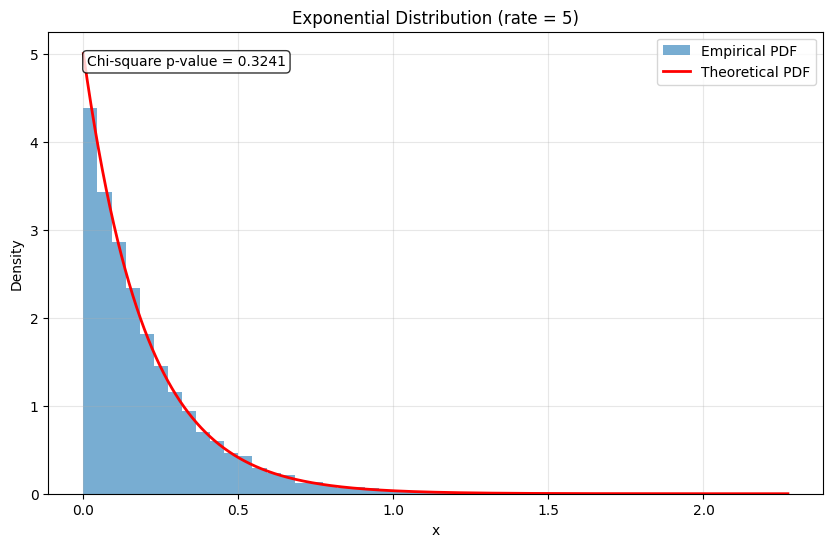

pvalue: 0.14709183670896206


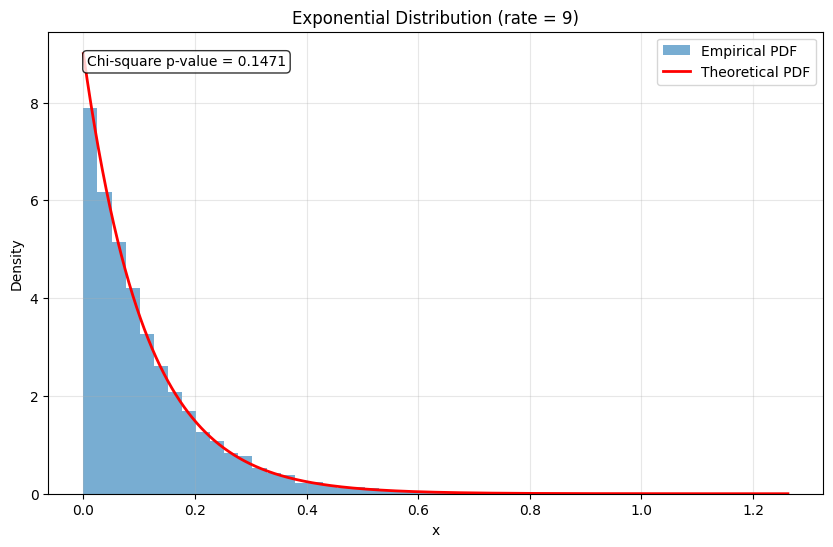

In [1565]:

rate = [0.5, 1, 3, 5, 9]
for element in rate: 
    # Simulate geometric sample 
    np.random.seed(42)
    n = 10000
    U = np.random.rand(n)
    exp_sample = exp_disp_gen(U,element)
 


    # Theorical pdf
    
    x = np.linspace(0, np.max(exp_sample), 10000)
    theoretical_pdf = element * np.exp(-element * x)
    
    bin_edges = np.array([
    0.0, 0.1, 0.2, 0.3, 0.5,
    0.8, 1.2, np.inf
        ])
    
    # Observed frequencies
    observed, _ = np.histogram(exp_sample, bins=bin_edges)
    
    # Expected frequencies
    cdf_vals = expon(scale=1/element).cdf(bin_edges)
    expected = len(exp_sample) * np.diff(cdf_vals)
    
    # Chi-square
    
    chi2_stat, p_value = chisquare(
        f_obs=observed,
        f_exp=expected
        )
    
    print("pvalue:", p_value)

    text = (
    f"Chi-square p-value = {p_value:.4f}"
     )

    
    plt.figure(figsize=(10, 6))

    plt.hist(exp_sample, bins=50, density=True,
            alpha=0.6, label="Empirical PDF")

    plt.plot(x, theoretical_pdf, 'r-', lw=2,
            label="Theoretical PDF")

    plt.title(f"Exponential Distribution (rate = {element})")

    plt.text(
    0.05, 0.95,
    text,
    transform=plt.gca().transAxes,
    va='top',
    bbox=dict(boxstyle='round', facecolor='white', alpha=0.8)
     )
    
    plt.xlabel("x")
    plt.ylabel("Density")
    plt.legend()
    plt.grid(alpha=0.3)

    plt.show()

##### (2) Normal distribution (at least using the Box–Muller method).



In [1566]:
# Normal distribution through box-Müller 
np.random.seed(42)

def norm_disp_gen(mu, std, n):
    U1 = np.random.rand(n)
    U2 = np.random.rand(n)
    Z = np.sqrt(-2*np.log(U1))*np.cos(2*np.pi*U2)

    return mu + std*Z

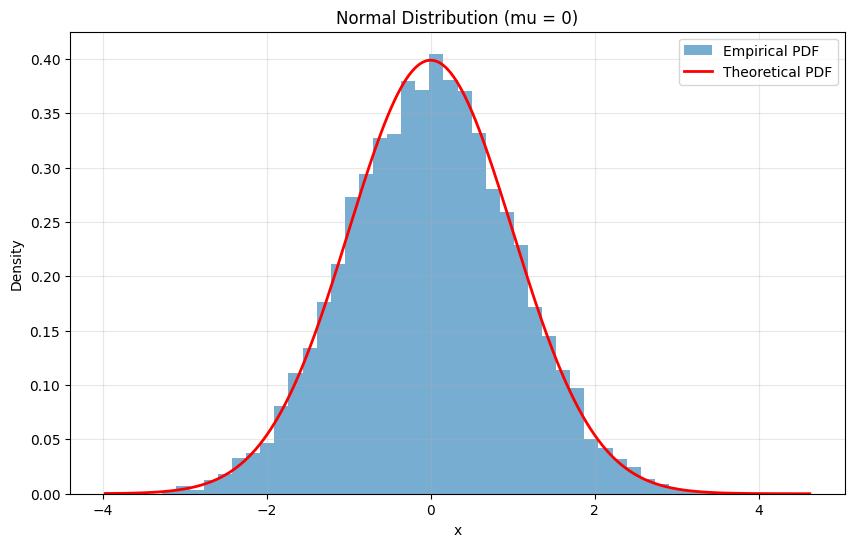

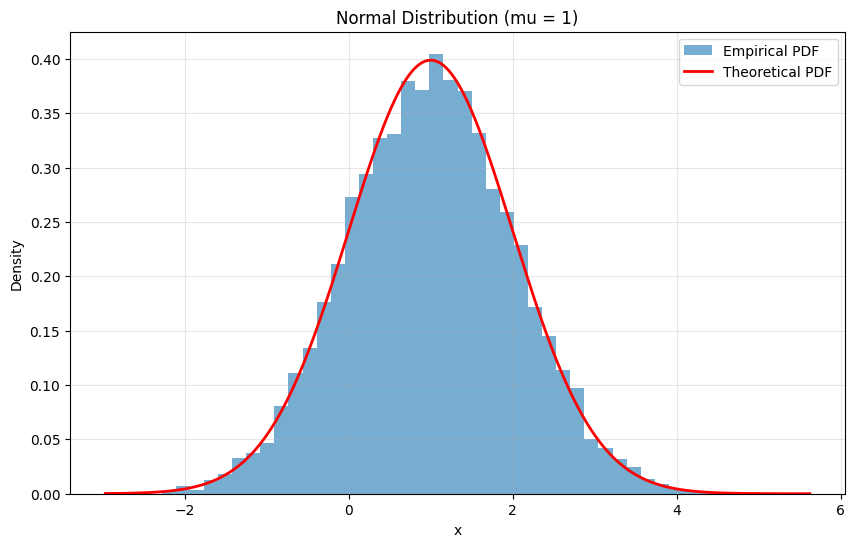

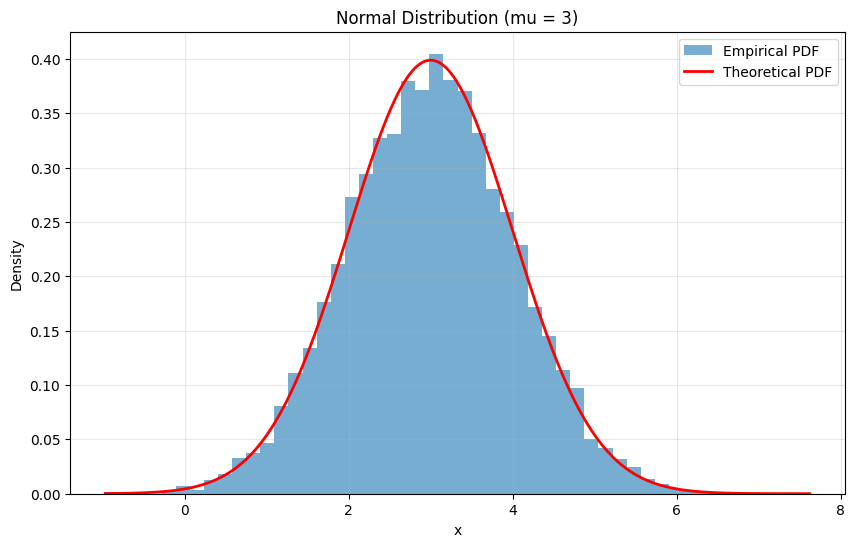

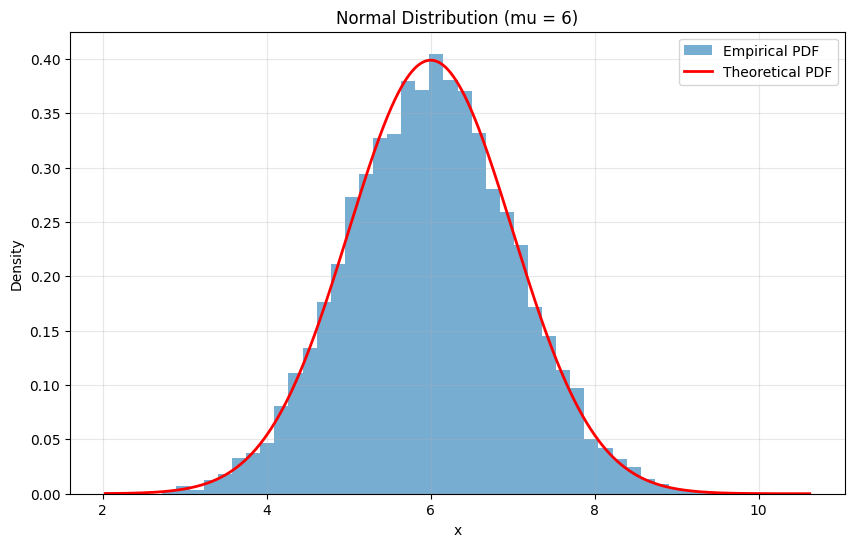

In [1567]:
mu = [0, 1, 3, 6]
std = 1 
n = 10000
for element in mu: 
    # Simulate geometric sample 
    np.random.seed(42)
    norm_sample = norm_disp_gen(element, std, n)
 


    # Theorical pdf
    
    x = np.linspace(np.min(norm_sample), np.max(norm_sample), 10000)
    theoretical_pdf_norm = (1 / (std * np.sqrt(2 * np.pi))) * \
           np.exp(-0.5 * ((x - element) / std) ** 2)


    
    plt.figure(figsize=(10, 6))

    plt.hist(norm_sample, bins=50, density=True,
            alpha=0.6, label="Empirical PDF")

    plt.plot(x, theoretical_pdf_norm, 'r-', lw=2,
            label="Theoretical PDF")

    plt.title(f"Normal Distribution (mu = {element})")

    
    plt.xlabel("x")
    plt.ylabel("Density")
    plt.legend()
    plt.grid(alpha=0.3)

    plt.show()

### Day 3

#### Exercise 4 

##### Part 1

In [1568]:
m = 10 
N = 10000 

Mean_interarrival_time = 1 # Mean interarrival time
Mean_service_time = 8 #Mean service time

A = Mean_interarrival_time * Mean_service_time 


In [1569]:

def Erlang_B_formula(m, A):
    t = A**m/math.factorial(m)
    n = 0 
    for i in range(m+1): 
        n += A**i/math.factorial(i)
    return t/n

def arrival_process_poisson(m, N, mean_interarrival_time, mean_service_time):
    # State
    time = 0.0
    arrivals = 0
    blocked_customers = 0

    # Each server has a "next departure time"
    servers = [float("inf")] * m  # label: server i is busy until servers[i]

    # First arrival
    next_arrival = random.expovariate(1 / mean_interarrival_time)

    while arrivals < N:

        
        next_departure = min(servers)
        next_departure_server = servers.index(next_departure)

        # Compare events
        if next_arrival < next_departure:
            time = next_arrival
            arrivals += 1

            # Check for free server
            free_server = None
            for i in range(m):
                if servers[i] == float("inf") or servers[i] <= time:
                    free_server = i
                    break

            if free_server is not None:
                service_time = random.expovariate(1 / mean_service_time)
                servers[free_server] = time + service_time
            else:
                blocked_customers += 1

            # schedule next arrival
            interarrival = random.expovariate(1 / mean_interarrival_time)
            next_arrival = time + interarrival

        else:
            # departure event
            time = next_departure
            servers[next_departure_server] = float("inf")

    return blocked_customers / N

In [1570]:
m = 10 
N = 10000 

Mean_interarrival_time = 1 # Mean interarrival time
Mean_service_time = 8 #Mean service time
A = Mean_interarrival_time * Mean_service_time
results = []
for i in range(50):
    frac = arrival_process_poisson(m, N, Mean_interarrival_time,Mean_service_time)
    results.append(frac)


In [1571]:
results

[0.1192,
 0.1117,
 0.1248,
 0.117,
 0.1269,
 0.1334,
 0.1244,
 0.1249,
 0.1179,
 0.1224,
 0.132,
 0.1274,
 0.1108,
 0.1197,
 0.1149,
 0.1091,
 0.1218,
 0.1158,
 0.1222,
 0.114,
 0.113,
 0.1185,
 0.1206,
 0.1301,
 0.1265,
 0.1186,
 0.1285,
 0.1241,
 0.1183,
 0.1126,
 0.1184,
 0.1319,
 0.1297,
 0.1271,
 0.1296,
 0.1136,
 0.1307,
 0.1326,
 0.1197,
 0.1288,
 0.1282,
 0.1261,
 0.1161,
 0.1285,
 0.1369,
 0.1211,
 0.123,
 0.1277,
 0.1151,
 0.1286]

In [1572]:
Analytical_result = Erlang_B_formula(m,A)
Analytical_result

0.12166106425295149

In [1573]:
def confidence_interval_95(results):
    results = np.array(results)
    n = len(results)

    mean = np.mean(results)
    std = np.std(results, ddof=1)  # sample std

    t_crit_1 = stats.t.ppf(0.025, df=n-1)
    t_crit_2 = stats.t.ppf(0.975, df=n-1)

    margin_1 = t_crit_1 * std / np.sqrt(n) + mean 
    margin_2 = t_crit_2 * std / np.sqrt(n) + mean

    return [margin_1, margin_2]

In [1574]:
confidence_interval_95(results)

[np.float64(0.12075454442516714), np.float64(0.12462545557483282)]

##### Part 2 

In [1585]:
def erlang(k, mean):
    return random.gammavariate(k, mean)

In [1586]:
def arrival_process_Erlang(m, N, mean_interarrival_time, mean_service_time, k =2):
    # State
    time = 0.0
    arrivals = 0
    blocked_customers = 0

    # Each server has a "next departure time"
    servers = [float("inf")] * m  # label: server i is busy until servers[i]

    # First arrival
    next_arrival = erlang(mean_interarrival_time, k)

    while arrivals < N:

        
        next_departure = min(servers)
        next_departure_server = servers.index(next_departure)

        # Compare events
        if next_arrival < next_departure:
            time = next_arrival
            arrivals += 1

            # Check for free server
            free_server = None
            for i in range(m):
                if servers[i] == float("inf") or servers[i] <= time:
                    free_server = i
                    break

            if free_server is not None:
                service_time = random.expovariate(1 / mean_service_time)
                servers[free_server] = time + service_time
            else:
                blocked_customers += 1

            # schedule next arrival
            interarrival = erlang(mean_interarrival_time, k)
            next_arrival = time + interarrival

        else:
            # departure event
            time = next_departure
            servers[next_departure_server] = float("inf")

    return blocked_customers / N

In [1587]:
m = 10 
N = 10000 

Mean_interarrival_time = 1 # Mean interarrival time
Mean_service_time = 8 #Mean service time
A = Mean_interarrival_time * Mean_service_time

arrival_process_Erlang(m, N, Mean_interarrival_time,Mean_service_time,2)

0.0059

In [1591]:
m = 10 
N = 10000 

Mean_interarrival_time = 1 # Mean interarrival time
Mean_service_time = 8 #Mean service time
A = Mean_interarrival_time * Mean_service_time
results = []
for i in range(50):
    frac = arrival_process_Erlang(m, N, Mean_interarrival_time,Mean_service_time,2)
    results.append(frac)

In [1592]:
confidence_interval_95(results)


[np.float64(0.004891146880632657), np.float64(0.005628853119367343)]

In [1593]:
2+2


4